In [12]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
from scipy.stats import linregress, theilslopes
import sys
from tqdm import tqdm

# --- PATH SETUP ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# --- LOCAL IMPORTS ---
%load_ext autoreload
%autoreload 2
from src.analysis import processing as proc
from src.analysis import plotting as viz
from src.analysis import metrics

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded.


In [15]:
def calculate_box_counts(coords,lower_limit=4,upper_divisor=16   ):
    """
    Returns the raw (box_size, count) arrays for a given cluster.
    """
    max_box_size = int(np.max(np.abs(coords))) + 1
    
    # Define scales: Powers of 2 from 8 up to R/16 
    upper_limit = max_box_size / upper_divisor
    scales = np.logspace(lower_limit, np.log2(upper_limit), num=30, base=2, dtype=int)
    scales = np.unique(scales) # Remove duplicates

    counts = []
    
    y_multiplier = int(max_box_size * 2 + 10000)
    coords_pos = coords + max_box_size # Shift to positive

    for eps in scales:
        grid_x = np.floor(coords_pos[:,0] / eps).astype(np.int64)
        grid_y = np.floor(coords_pos[:,1] / eps).astype(np.int64)
        grid_hash = grid_x + (grid_y * y_multiplier)
        unique_count = len(np.unique(grid_hash))
        counts.append(unique_count)
    
    return scales, np.array(counts)


In [25]:
# --- LOAD ONE CLUSTER PER MODEL/SIZE ---
samples = {}
models = ['Lattice', 'OffLattice', 'Hybrid'] 
sizes = ['1M', '10M']

print(f"Searching for data in: {os.path.join(project_root, 'results', 'analysis_clusters')}")

for model in models:
    for size in sizes:
        base_dir = os.path.join(project_root, 'results', 'analysis_clusters', model, size)
        search_pattern = os.path.join(base_dir, "*.npz")
        
        # finds all files matching the pattern
        files = glob.glob(search_pattern)
        
        if len(files) > 0:
            # picks the first file found (random seed)
            target_file = files[0]
            try:
                coords = proc.load_cluster(target_file)
                samples[f"{model}_{size}"] = coords
                print(f"✅ Loaded {model}_{size}: {coords.shape} (File: {os.path.basename(target_file)})")
                
            except Exception as e:
                print(f" Error loading {model}_{size}: {e}")
        else:
            print(f" No files found for {model}/{size}")


Searching for data in: /Users/ramsaydavis/dla/results/analysis_clusters
✅ Loaded Lattice_1M: (1000000, 2) (File: 837.npz)
✅ Loaded Lattice_10M: (10000000, 2) (File: 10057.npz)
✅ Loaded OffLattice_1M: (1000001, 2) (File: 1347.npz)
✅ Loaded OffLattice_10M: (10000001, 2) (File: 10123.npz)
✅ Loaded Hybrid_1M: (1000001, 2) (File: 2114.npz)
✅ Loaded Hybrid_10M: (10000001, 2) (File: 10255.npz)


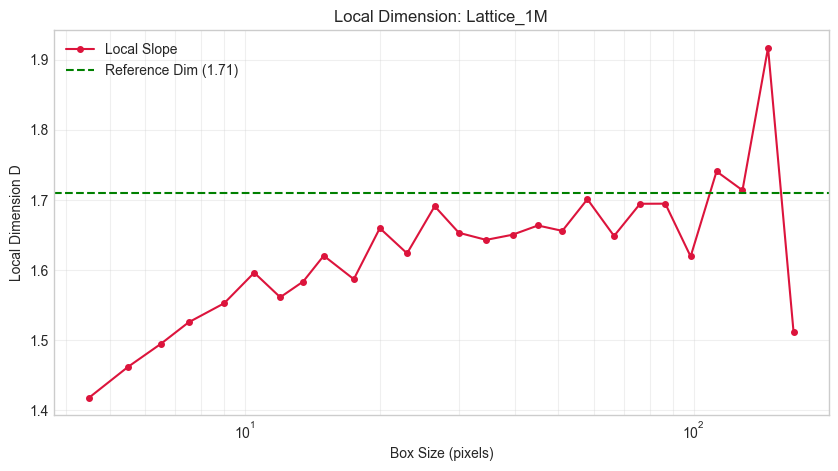

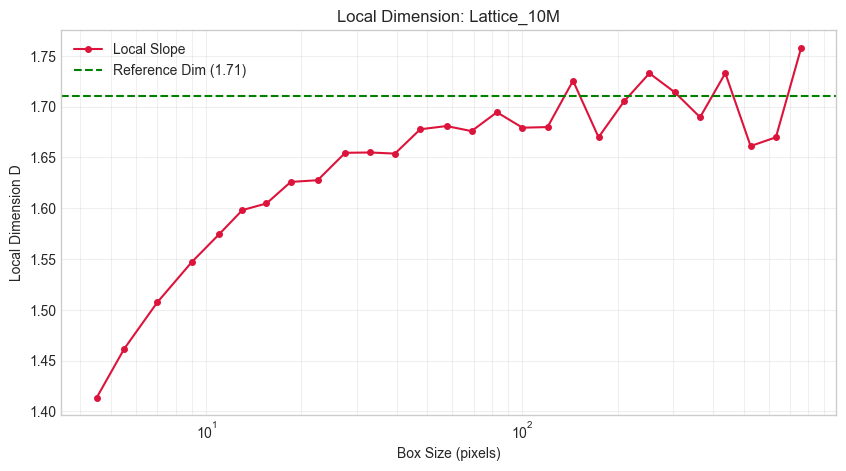

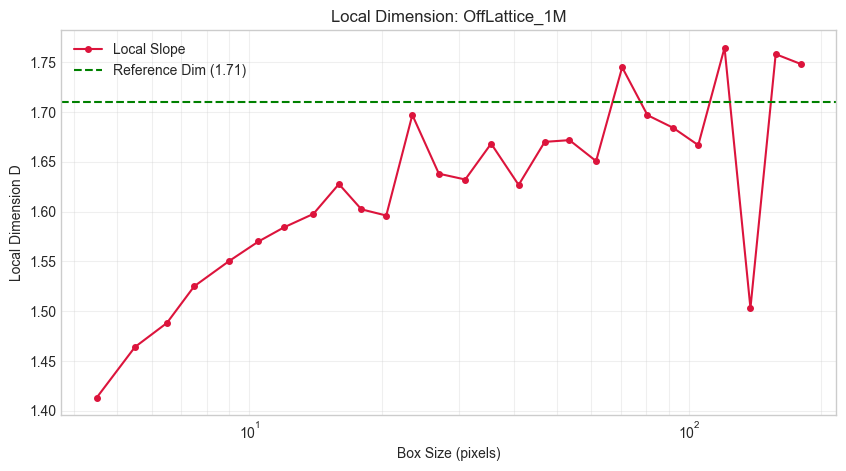

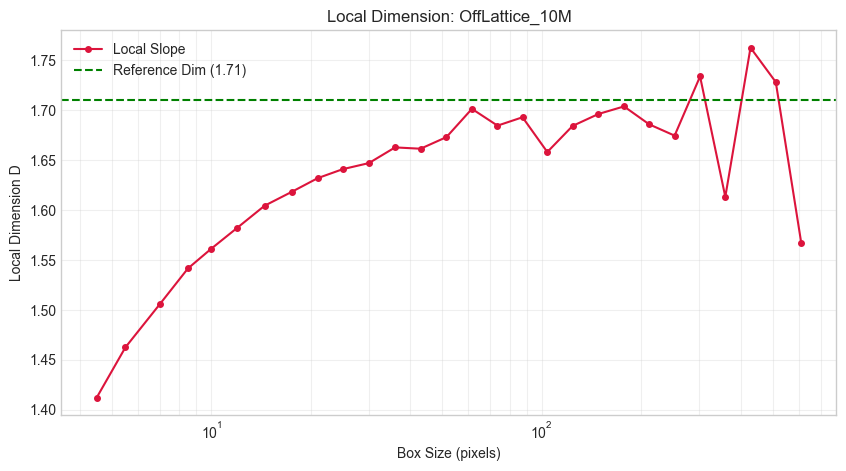

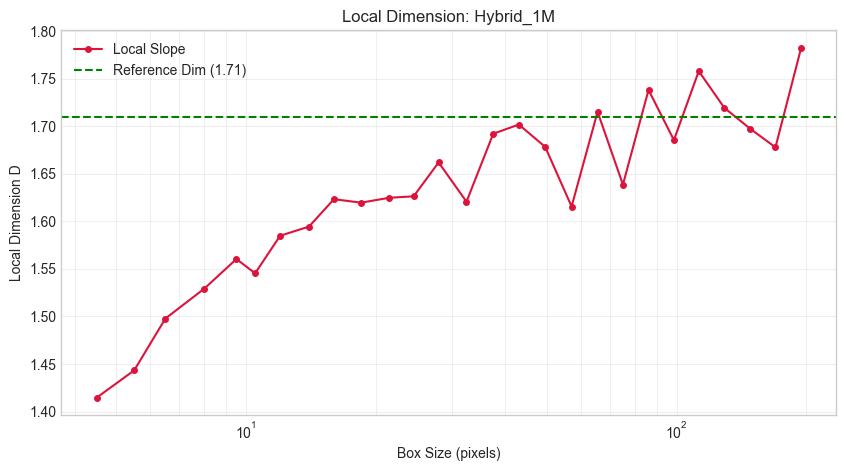

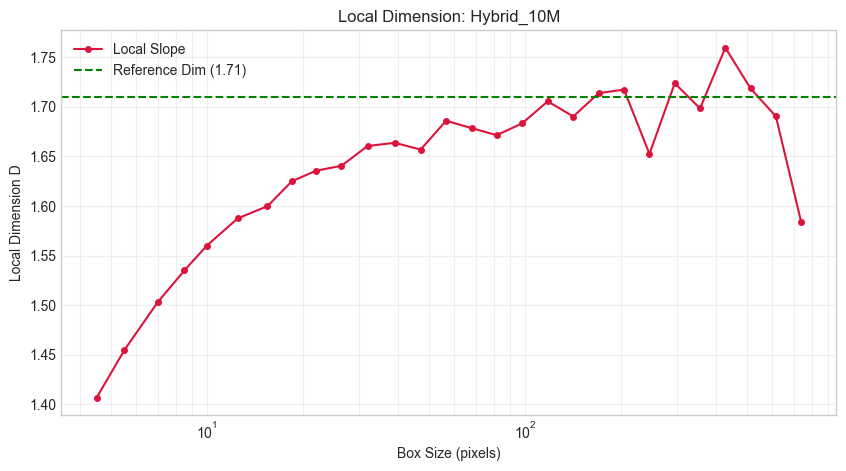

In [4]:
def plot_local_dimension(coords, title="Local Dimension Analysis"):
    scales, counts = calculate_box_counts(coords)
    
    log_eps = np.log(scales)
    log_N = np.log(counts)
    
    # Derivative: d(log N) / d(log eps)
    # use central difference for smoother derivative
    local_dim = -np.diff(log_N) / np.diff(log_eps) 
    mid_points = (scales[:-1] + scales[1:]) / 2
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(mid_points, local_dim, 'o-', color='crimson', markersize=4, label='Local Slope')
    
    # Reference Lines
    ax.axhline(1.71, color='green', linestyle='--', label='Reference Dim (1.71)')
    
    ax.set_xscale('log')
    ax.set_xlabel('Box Size (pixels)')
    ax.set_ylabel('Local Dimension D')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    
    return mid_points, local_dim

# Run on clusters 
for name, coords in samples.items():
    plot_local_dimension(coords, title=f"Local Dimension: {name}")
    plt.show() # Ensure each plot renders


--- Lattice_1M ---
Standard Fit (L2):      1.6299
Robust Fit (Theil-Sen): 1.6427
Uncertainty Cone:       0.0317


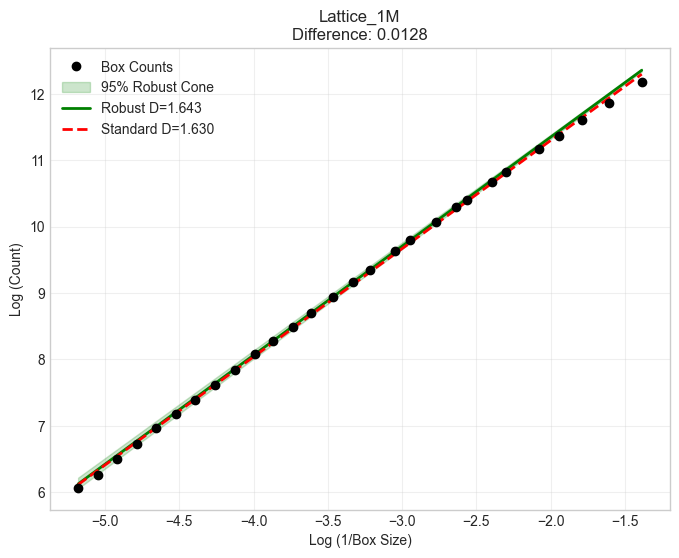

--- Lattice_10M ---
Standard Fit (L2):      1.6567
Robust Fit (Theil-Sen): 1.6709
Uncertainty Cone:       0.0271


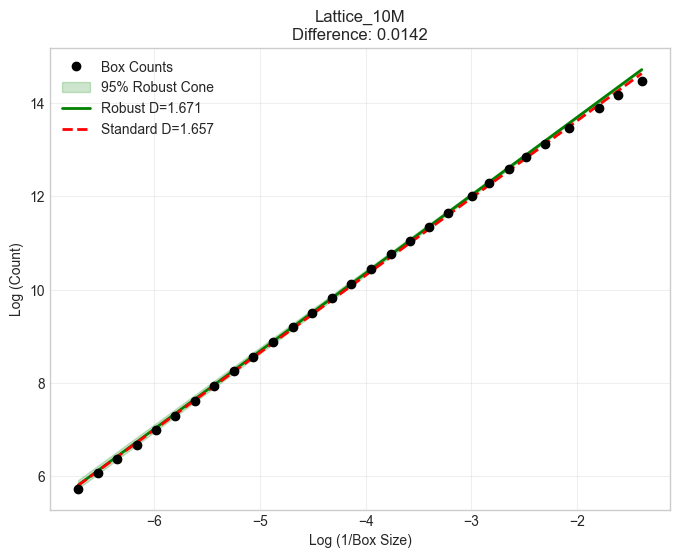

--- OffLattice_1M ---
Standard Fit (L2):      1.6296
Robust Fit (Theil-Sen): 1.6415
Uncertainty Cone:       0.0288


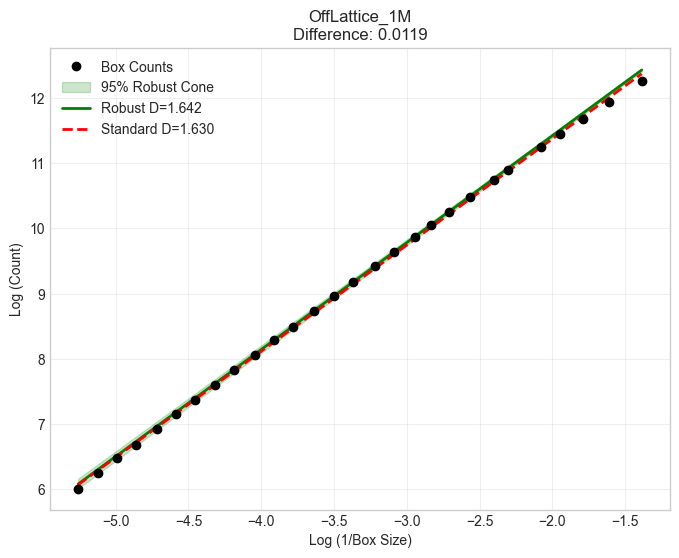

--- OffLattice_10M ---
Standard Fit (L2):      1.6502
Robust Fit (Theil-Sen): 1.6648
Uncertainty Cone:       0.0280


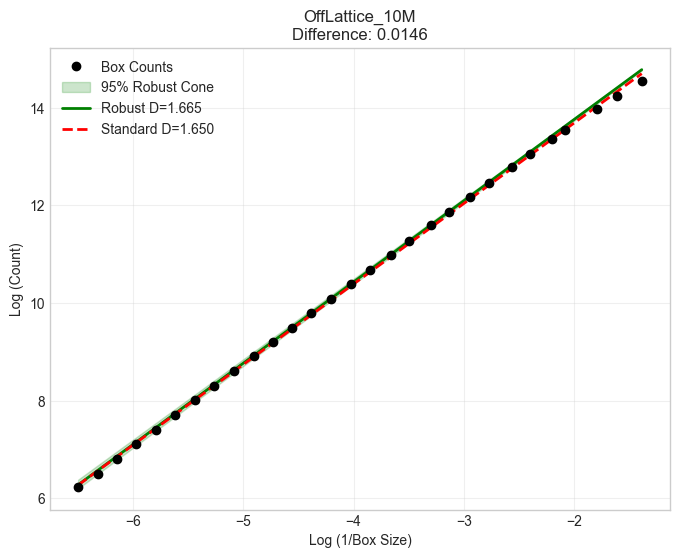

--- Hybrid_1M ---
Standard Fit (L2):      1.6358
Robust Fit (Theil-Sen): 1.6468
Uncertainty Cone:       0.0366


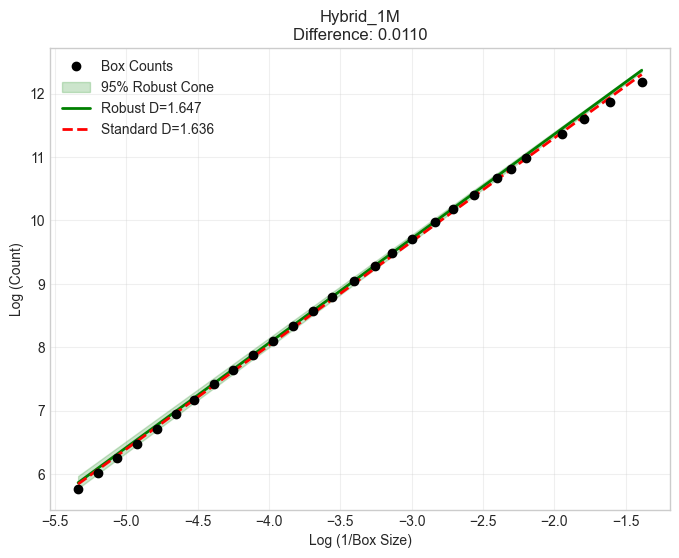

--- Hybrid_10M ---
Standard Fit (L2):      1.6549
Robust Fit (Theil-Sen): 1.6681
Uncertainty Cone:       0.0286


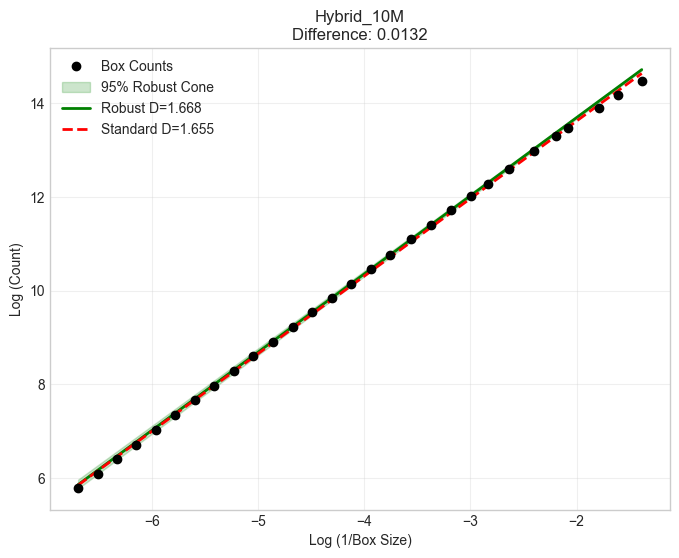

In [5]:
def analyse_slope_robustness(coords, title="Regression Robustness"):
    # raw box-counting data
    scales, counts = calculate_box_counts(coords)
    
    # Log-Log Transformation
    x = np.log(1 / scales)
    y = np.log(counts)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # standard regression
    res = linregress(x, y)
    D_l2 = res.slope  # Slope is D
    
    # using theil-sen
    # returns median_slope, intercept, lower_bound_slope, upper_bound_slope
    slope_ts, intercept_ts, low_slope, high_slope = theilslopes(y, x, 0.95)
    D_robust = slope_ts
    
    # Plot Data
    ax.plot(x, y, 'ko', label='Box Counts', zorder=3)
    
    # Define Range for lines
    x_range = np.array([min(x), max(x)])
    
    # Plot 95% Confidence Interval of Slope
    y_low = intercept_ts + low_slope * x_range
    y_high = intercept_ts + high_slope * x_range
    ax.fill_between(x_range, y_low, y_high, color='green', alpha=0.2, label='95% Robust Cone')
    
    # Plot The Fits
    ax.plot(x_range, intercept_ts + slope_ts * x_range, 'g-', linewidth=2, label=f'Robust D={D_robust:.3f}')
    ax.plot(x_range, res.intercept + res.slope * x_range, 'r--', linewidth=2, label=f'Standard D={D_l2:.3f}')
    
    # Formatting
    ax.set_xlabel("Log (1/Box Size)")
    ax.set_ylabel("Log (Count)")
    ax.set_title(f"{title}\nDifference: {abs(D_l2 - D_robust):.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"--- {title} ---")
    print(f"Standard Fit (L2):      {D_l2:.4f}")
    print(f"Robust Fit (Theil-Sen): {D_robust:.4f}")
    print(f"Uncertainty Cone:       {high_slope - low_slope:.4f}")
    
    return D_l2, D_robust

# run on samples
for name, coords in samples.items():
    analyse_slope_robustness(coords, title=name)
    plt.show()

Analyzing convergence for Lattice (1000 files loaded)...


/var/folders/4t/j6s0_pjn51gcp0q2x317m5n40000gn/T/ipykernel_78010/1113861666.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


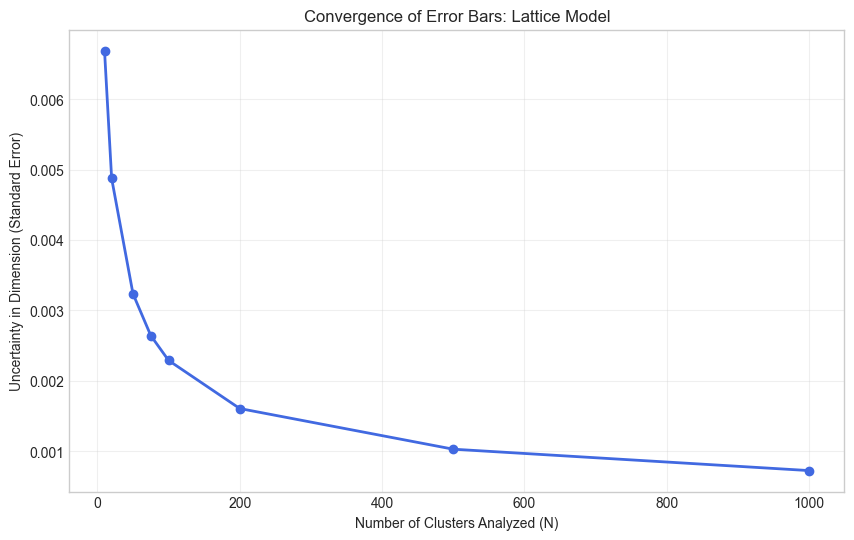

Analyzing convergence for Lattice (100 files loaded)...


/var/folders/4t/j6s0_pjn51gcp0q2x317m5n40000gn/T/ipykernel_78010/1113861666.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


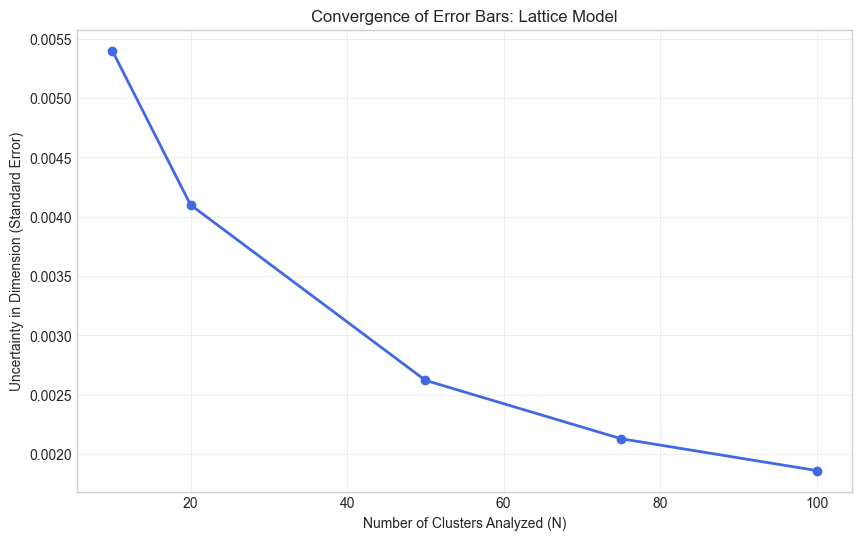

In [6]:

def plot_convergence_real(model_name="Lattice", size_label="1M"):
    """
    Loads real scalar data and plots how the Standard Error of D shrinks with N.
    """
    file_path = f"../results/processed/{model_name}_{size_label}_scalars.csv"
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    df = pd.read_csv(file_path)
    
    # 2. Convert to Dimension (D = 1/beta)
    # We filter out any failed runs (NaNs)
    valid_betas = df['beta'].dropna()
    all_dims = 1.0 / valid_betas.values
    
    total_files = len(all_dims)
    print(f"Analyzing convergence for {model_name} ({total_files} files loaded)...")
    
    # Define Sample Sizes to Test
    sample_sizes = [10, 20, 50, 75, 100, 200, 500, 1000]
    sample_sizes = [n for n in sample_sizes if n <= total_files]
    
    std_errors = []
    
    # 4. Bootstrap Loop
    for n in sample_sizes:
        # We repeat sampling 100 times to smooth out  curve
        bootstrap_errors = []
        for _ in range(100):
            subset = np.random.choice(all_dims, size=n, replace=False)
            
            # Calculate Standard Error
            sem = np.std(subset) / np.sqrt(n)
            bootstrap_errors.append(sem)
            
        # Average the error for this sample size
        std_errors.append(np.mean(bootstrap_errors))
        
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(sample_sizes, std_errors, 'o-', linewidth=2, color='royalblue')

    plt.xlabel("Number of Clusters Analyzed (N)")
    plt.ylabel("Uncertainty in Dimension (Standard Error)")
    plt.title(f"Convergence of Error Bars: {model_name} Model")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    
    
    plt.show()

# --- EXECUTION ---
# Use your most "standard" model to prove the statistics
plot_convergence_real("Lattice", "1M") 
plot_convergence_real("Lattice",'10M')

--- Lattice Statistics ---
1M  Growth Mean: 1.7033 | Box Mean: 1.6611
10M Growth Mean: 1.6960 | Box Mean: 1.6700


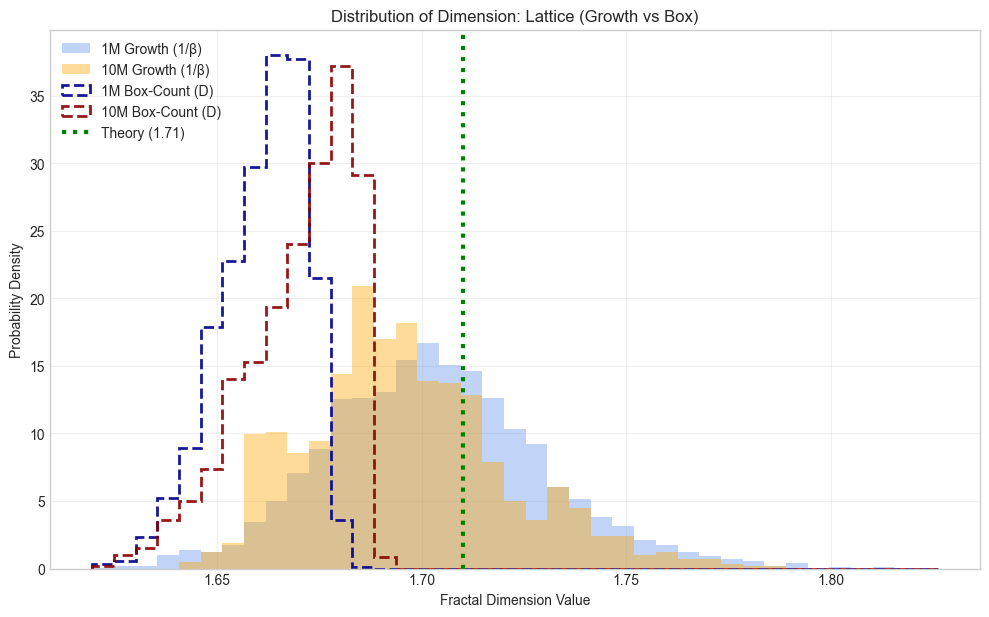

--- OffLattice Statistics ---
1M  Growth Mean: 1.7171 | Box Mean: 1.6563
10M Growth Mean: 1.7170 | Box Mean: 1.6655


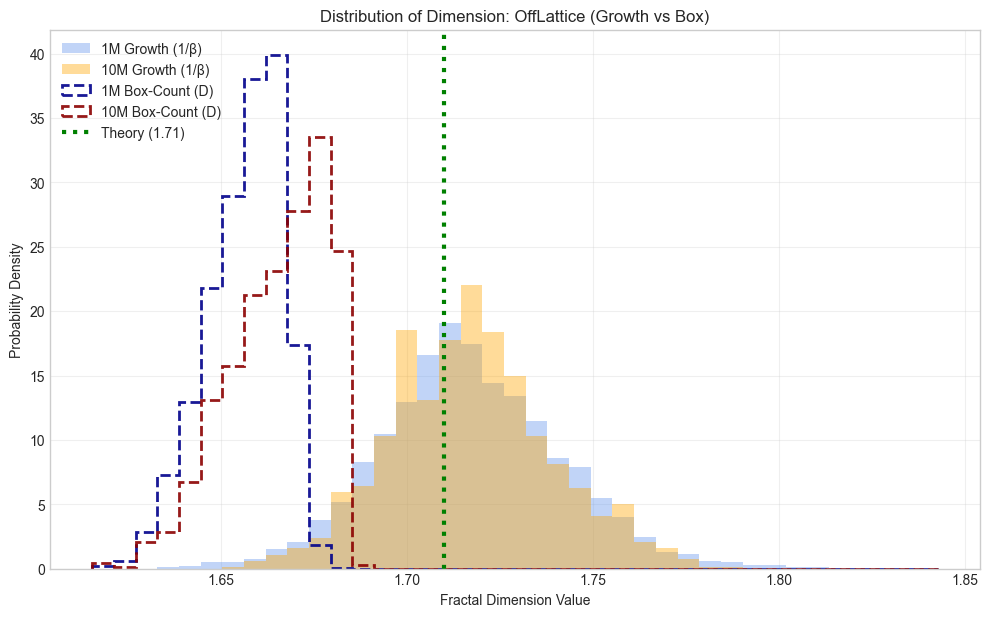

--- Hybrid Statistics ---
1M  Growth Mean: 1.6980 | Box Mean: 1.6607
10M Growth Mean: 1.6893 | Box Mean: 1.6697


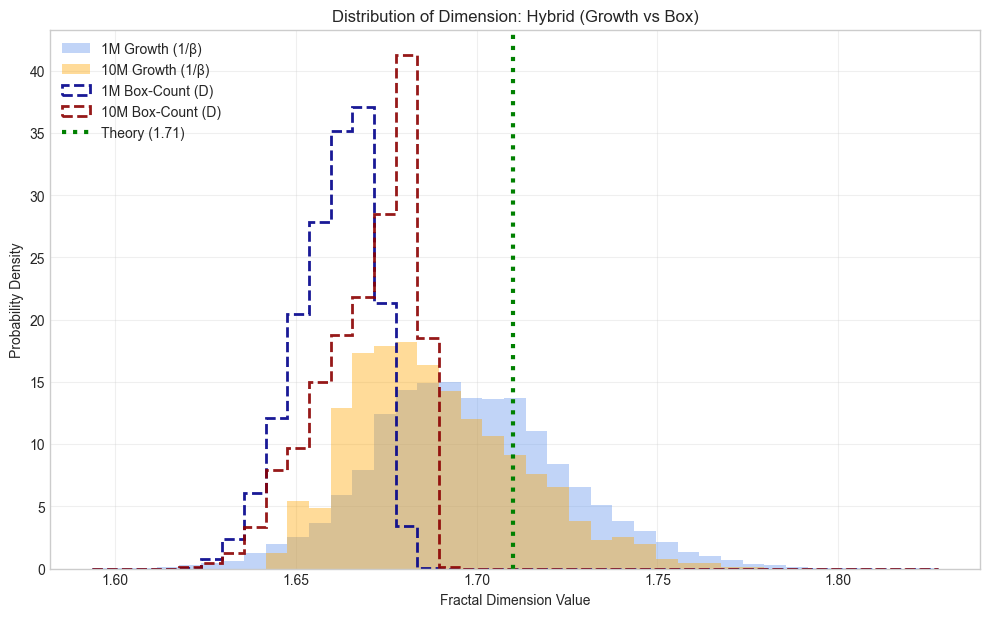

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def compare_evolution_full_density(model_name="Lattice"):
    """
    Plots 4 overlayed histograms using PROBABILITY DENSITY:
    1. 1M Growth Dimension (1/beta)
    2. 10M Growth Dimension (1/beta)
    3. 1M Box-Counting Dimension (D)
    4. 10M Box-Counting Dimension (D)
    """
    # 1. Define Paths
    path_1m = f"../results/processed/{model_name}_1M_scalars.csv"
    path_10m = f"../results/processed/{model_name}_10M_scalars.csv"
    
    # 2. Check existence
    if not os.path.exists(path_1m) or not os.path.exists(path_10m):
        print(f"Skipping {model_name}: Data files not found.")
        return

    # 3. Load Data
    df_1m = pd.read_csv(path_1m)
    df_10m = pd.read_csv(path_10m)
    
    # 4. Extract Data & Handle NaNs
    
    # --- Growth Dimension (1/beta) ---
    beta_1m = df_1m['beta'].dropna()
    d_growth_1m = 1.0 / beta_1m[beta_1m > 0]
    
    beta_10m = df_10m['beta'].dropna()
    d_growth_10m = 1.0 / beta_10m[beta_10m > 0]
    
    # --- Box-Counting Dimension (D) ---
    if 'D' in df_1m.columns:
        d_box_1m = df_1m['D'].dropna()
        d_box_1m = d_box_1m[d_box_1m > 0] 
    else:
        d_box_1m = []
        print("Warning: 'D' column not found in 1M data")

    if 'D' in df_10m.columns:
        d_box_10m = df_10m['D'].dropna()
        d_box_10m = d_box_10m[d_box_10m > 0]
    else:
        d_box_10m = []
        print("Warning: 'D' column not found in 10M data")
    
    print(f"--- {model_name} Statistics ---")
    print(f"1M  Growth Mean: {np.mean(d_growth_1m):.4f} | Box Mean: {np.mean(d_box_1m):.4f}")
    print(f"10M Growth Mean: {np.mean(d_growth_10m):.4f} | Box Mean: {np.mean(d_box_10m):.4f}")
    
    plt.figure(figsize=(12, 7))
    

    all_data = np.concatenate([d_growth_1m, d_growth_10m, d_box_1m, d_box_10m])
    bins = np.linspace(np.min(all_data), np.max(all_data), 40)
    
    # --- PLOT GROWTH DIMENSIONS (Solid Colors) ---
    # 1M Growth (Blue, Solid)
    plt.hist(d_growth_1m, bins=bins, alpha=0.4, density=True, 
             label=f'1M Growth (1/β)', color='cornflowerblue', edgecolor='none')
    
    # 10M Growth (Orange, Solid)
    plt.hist(d_growth_10m, bins=bins, alpha=0.4, density=True,
             label=f'10M Growth (1/β)', color='orange', edgecolor='none')

    # --- PLOT BOX DIMENSIONS (Hatched/Step) ---
    # 1M Box (Blue, Hatched/Line)
    plt.hist(d_box_1m, bins=bins, alpha=0.9, density=True,     
             histtype='step', linewidth=2,
             label=f'1M Box-Count (D)', color='darkblue', linestyle='--')
    
    # 10M Box (Orange, Hatched/Line)
    plt.hist(d_box_10m, bins=bins, alpha=0.9, density=True,   
             histtype='step', linewidth=2,
             label=f'10M Box-Count (D)', color='darkred', linestyle='--')
    
    # --- Reference Lines ---
    plt.axvline(1.71, color='green', linestyle=':', linewidth=3, label='Theory (1.71)')
    
    # Formatting
    plt.xlabel("Fractal Dimension Value")
    plt.ylabel("Probability Density") # <--- UPDATED LABEL
    plt.title(f"Distribution of Dimension: {model_name} (Growth vs Box)")
    plt.legend(loc='upper left', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EXECUTION ---
compare_evolution_full_density("Lattice")
compare_evolution_full_density("OffLattice")
compare_evolution_full_density("Hybrid")

testing grwoth rate robustness

--- Lattice_1M ---
Standard Beta (L2):      0.5872  (D = 1.703)
Robust Beta (Theil-Sen): 0.5871  (D = 1.703)
Difference:     0.0000
Uncertainty Cone:       0.0011


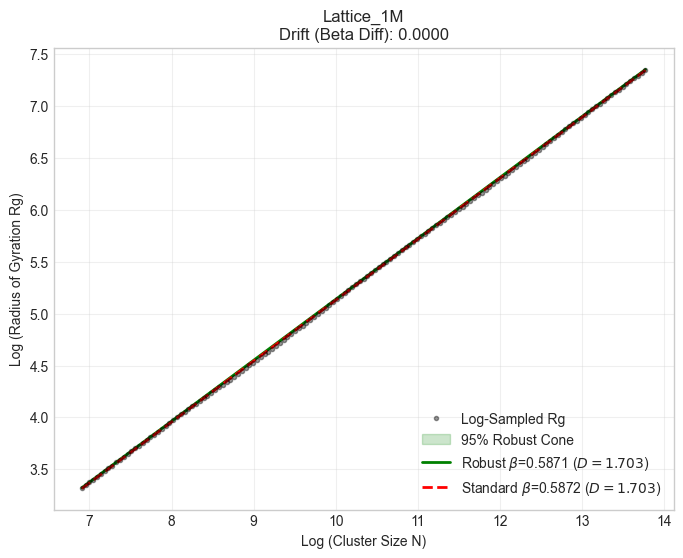

--- Lattice_10M ---
Standard Beta (L2):      0.6017  (D = 1.662)
Robust Beta (Theil-Sen): 0.6050  (D = 1.653)
Difference:     0.0033
Uncertainty Cone:       0.0030


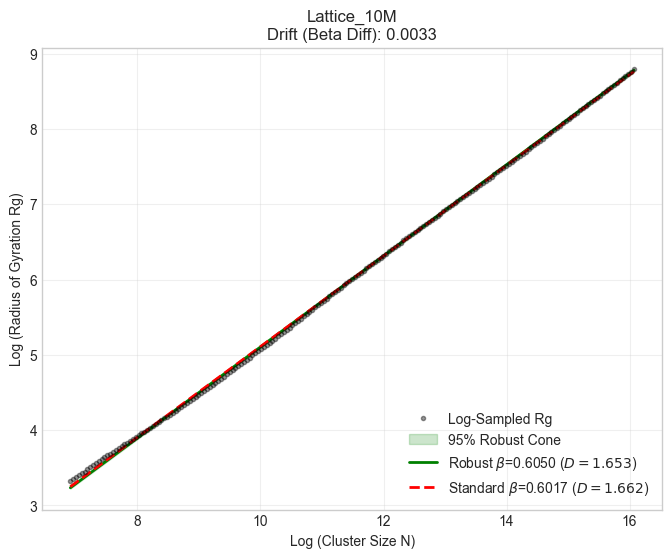

--- OffLattice_1M ---
Standard Beta (L2):      0.5839  (D = 1.713)
Robust Beta (Theil-Sen): 0.5827  (D = 1.716)
Difference:     0.0012
Uncertainty Cone:       0.0032


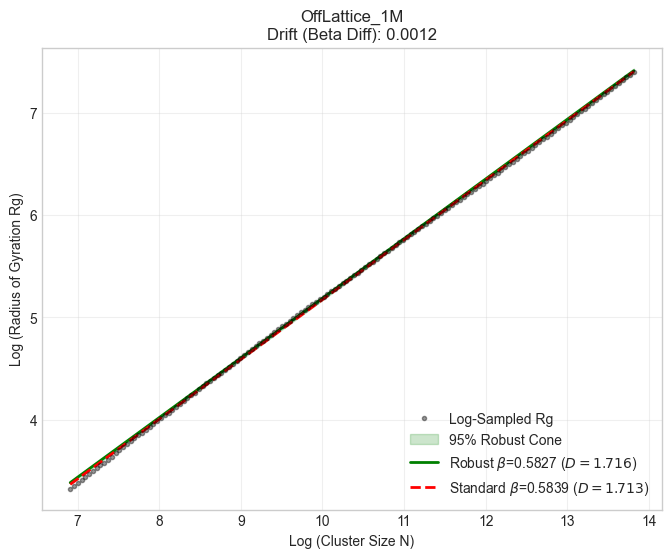

--- OffLattice_10M ---
Standard Beta (L2):      0.5915  (D = 1.690)
Robust Beta (Theil-Sen): 0.5894  (D = 1.697)
Difference:     0.0021
Uncertainty Cone:       0.0026


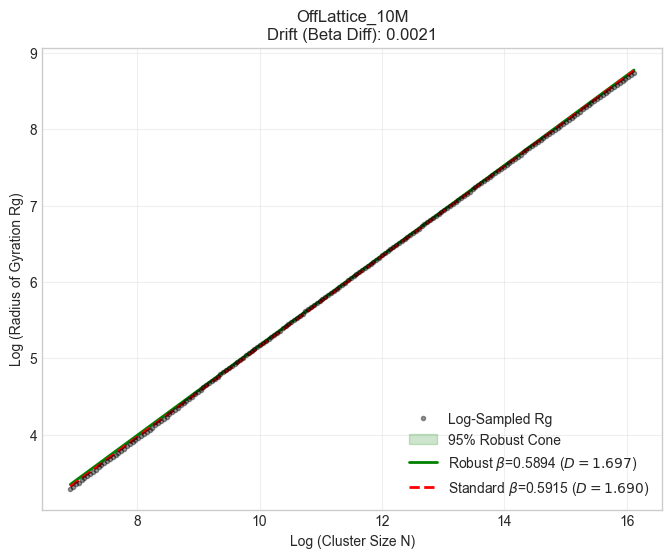

--- Hybrid_1M ---
Standard Beta (L2):      0.6066  (D = 1.649)
Robust Beta (Theil-Sen): 0.6066  (D = 1.648)
Difference:     0.0001
Uncertainty Cone:       0.0036


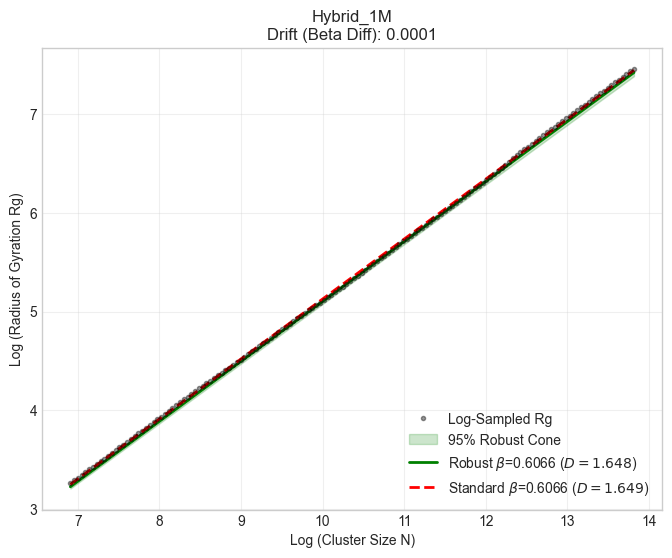

--- Hybrid_10M ---
Standard Beta (L2):      0.5929  (D = 1.687)
Robust Beta (Theil-Sen): 0.5900  (D = 1.695)
Difference:     0.0029
Uncertainty Cone:       0.0065


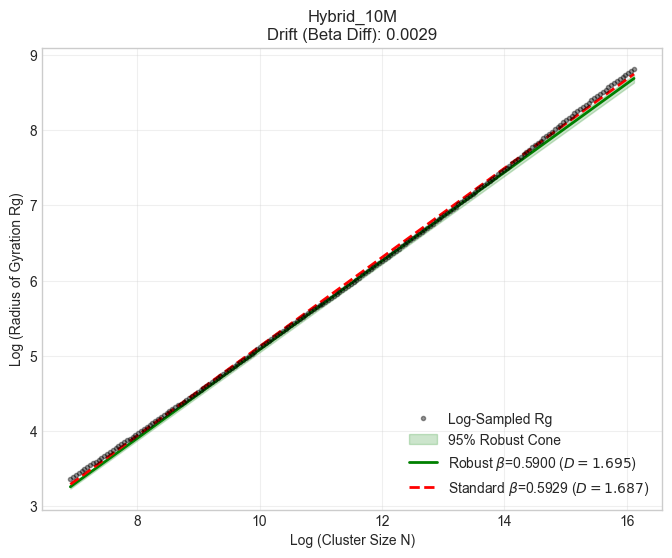

In [8]:
def sample_growth(coords, fit_start=1000):
    """
    Returns the log-resampled (N, Rg) arrays for a given cluster.
    - Calculates Rg relative to seed (origin) to match supervisor.
    - Resamples time logarithmically.
    """
    N_full = np.arange(1, len(coords) + 1)
    r_sq = np.sum(coords**2, axis=1) # Squared dist from (0,0)
    cum_r_sq = np.cumsum(r_sq)       # Cumulative sum
    Rg_full = np.sqrt(cum_r_sq / N_full) # Rg trajectory

    # 2. Log-Resampling
    # sample ~50 points per power of 10
    if len(coords) < fit_start:
        return np.array([]), np.array([])

    start_log = np.log10(fit_start)
    end_log = np.log10(len(coords))
    
    num_samples = int(50 * (end_log - start_log)) 
    
    log_indices = np.unique(np.logspace(start_log, end_log, num=num_samples).astype(int))
    log_indices = log_indices[log_indices < len(coords)] # Clip to valid range
    
    # Extract Resampled Data
    t_sampled = N_full[log_indices]
    rg_sampled = Rg_full[log_indices]
    
    return t_sampled, rg_sampled

def analyse_growth_robustness(coords, title="Growth Robustness"):
    # 1. Get Log-Resampled Data
    N_vals, Rg_vals = sample_growth(coords)
    
    if len(N_vals) < 10:
        print(f"Skipping {title}: Not enough data points.")
        return np.nan, np.nan

    # 2. Log-Log Transformation
    x = np.log(N_vals)
    y = np.log(Rg_vals)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 3. Fits
    # A. Standard Regression (L2)
    res = linregress(x, y)
    beta_l2 = res.slope 
    D_l2 = 1.0 / beta_l2
    
    # B. Theil-Sen
    beta_ts, intercept_ts, low_slope, high_slope = theilslopes(y, x, 0.95)
    D_robust = 1.0 / beta_ts
    
    # 4. Plot Data
    ax.plot(x, y, 'ko', markersize=3, alpha=0.4, label='Log-Sampled Rg', zorder=3)
    
    # Define Range for lines
    x_range = np.array([min(x), max(x)])
    
    # Plot 95% Confidence Interval of Slope (Theil-Sen)
    y_low = intercept_ts + low_slope * x_range
    y_high = intercept_ts + high_slope * x_range
    ax.fill_between(x_range, y_low, y_high, color='green', alpha=0.2, label='95% Robust Cone')
    
    # Plot The Fits
    # Robust (Green)
    ax.plot(x_range, intercept_ts + beta_ts * x_range, 'g-', linewidth=2, 
            label=f'Robust $\\beta$={beta_ts:.4f} ($D={D_robust:.3f}$)')
    # Standard (Red Dashed)
    ax.plot(x_range, res.intercept + res.slope * x_range, 'r--', linewidth=2, 
            label=f'Standard $\\beta$={beta_l2:.4f} ($D={D_l2:.3f}$)')
    
    # 5. Formatting
    ax.set_xlabel("Log (Cluster Size N)")
    ax.set_ylabel("Log (Radius of Gyration Rg)")
    
    # Calculate difference
    diff = abs(beta_l2 - beta_ts)
    ax.set_title(f"{title}\nDrift (Beta Diff): {diff:.4f}")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    print(f"--- {title} ---")
    print(f"Standard Beta (L2):      {beta_l2:.4f}  (D = {D_l2:.3f})")
    print(f"Robust Beta (Theil-Sen): {beta_ts:.4f}  (D = {D_robust:.3f})")
    print(f"Difference:     {diff:.4f}")
    print(f"Uncertainty Cone:       {high_slope - low_slope:.4f}")
    
    return beta_l2, beta_ts

# --- RUN ON SAMPLES ---
# Assuming 'samples' dict is preloaded with keys (names) and values (coords)
if 'samples' in locals():
    for name, coords in samples.items():
        analyse_growth_robustness(coords, title=name)
        plt.show()
else:
    print("Please ensure 'samples' dictionary is loaded with coordinate data.")

In [16]:
for name, coords in samples.items():
    print(name)

Lattice_1M
Lattice_10M
OffLattice_1M
OffLattice_10M
Hybrid_1M
Hybrid_10M


Figure saved successfully to: ../latex/images/box_regression_robustness.pdf


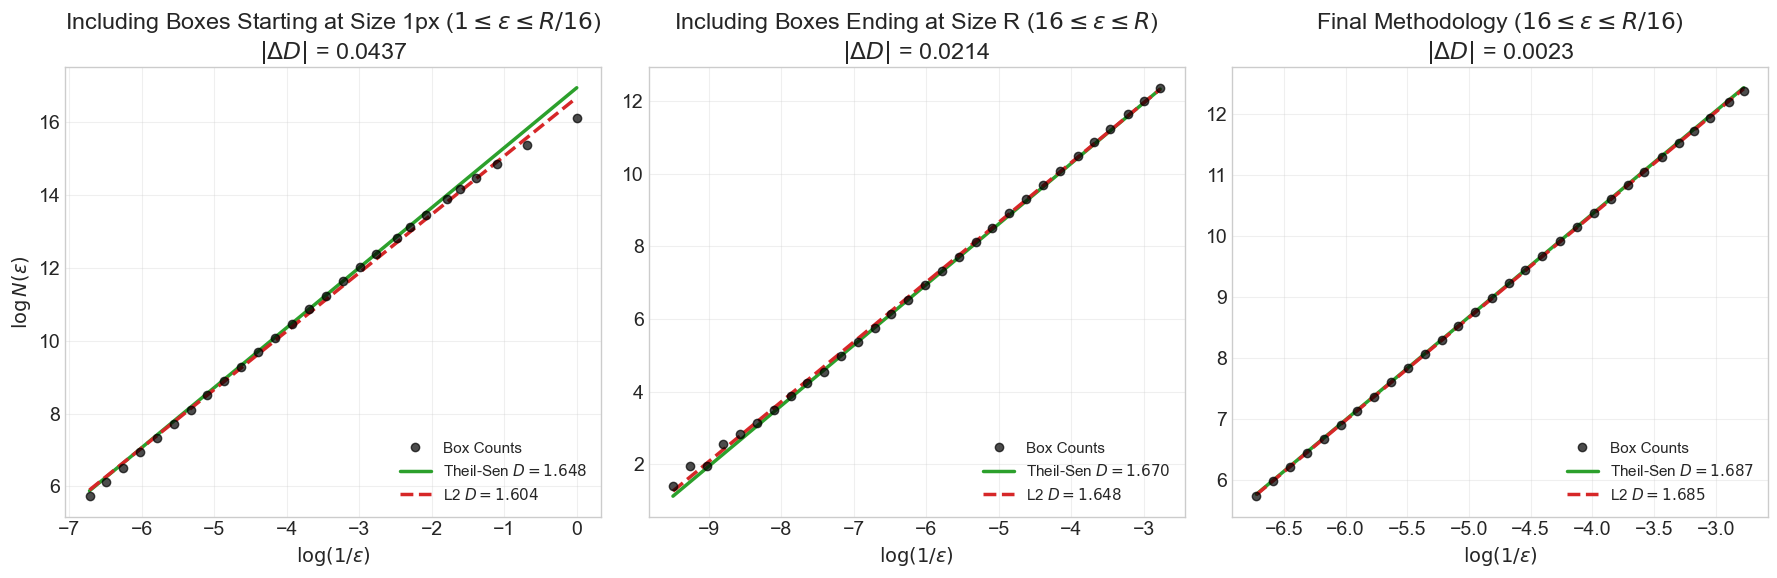

In [19]:
def plot_regression_on_ax(coords, ax, title, lower_limit, upper_divisor):
    """
    Plots the L2 vs Theil-Sen regression onto a specific Matplotlib axis.
    """
    # 1. Get raw box-counting data
    scales, counts = calculate_box_counts(coords, lower_limit, upper_divisor)
    
    # 2. Log-Log Transformation
    x = np.log(1 / scales)
    y = np.log(counts)
    
    # 3. Standard regression (L2)
    res = linregress(x, y)
    D_l2 = res.slope 
    
    # 4. Robust regression (Theil-Sen)
    slope_ts, intercept_ts, low_slope, high_slope = theilslopes(y, x, 0.95)
    D_robust = slope_ts
    
    # 5. Plot Data Points
    ax.plot(x, y, 'ko', label='Box Counts', zorder=3, alpha=0.7)
    
    # 6. Define Range for drawing lines
    x_range = np.array([min(x), max(x)])
    
    # 7. Plot 95% Confidence Interval of Theil-Sen Slope
    """ y_low = intercept_ts + low_slope * x_range
    y_high = intercept_ts + high_slope * x_range
    ax.fill_between(x_range, y_low, y_high, color='tab:green', alpha=0.15, label='95% Robust Cone')
    """
    # 8. Plot The Fits
    ax.plot(x_range, intercept_ts + slope_ts * x_range, color='tab:green', linestyle='-', linewidth=2.5, label=f'Theil-Sen $D={D_robust:.3f}$')
    ax.plot(x_range, res.intercept + res.slope * x_range, color='tab:red', linestyle='--', linewidth=2.5, label=f'L2 $D={D_l2:.3f}$')
    
    # 9. Formatting
    ax.set_xlabel("$\log(1/\epsilon)$")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("$\log N(\epsilon)$") # Only show Y label on the far left plot
        
    ax.set_title(f"{title}\n$|\\Delta D|$ = {abs(D_l2 - D_robust):.4f}")
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)


# ==========================================
# Script to Generate the 1x3 Grid Figure
# ==========================================

# NOTE: You will need to load a single 'coords' array here!
# For example, load one Lattice 10M .npz file and extract the final snapshot coordinates.
coords = samples["Lattice_10M"]

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Scenario A: Microscopic Noise Included (Starts at 1px)
plot_regression_on_ax(coords, axes[0], "Including Boxes Starting at Size 1px ($1 \leq \epsilon \leq R/16$)", lower_limit=0, upper_divisor=16)

# Scenario B: Macroscopic Flattening Included (Ends at R)
plot_regression_on_ax(coords, axes[1], "Including Boxes Ending at Size R ($16 \leq \epsilon \leq R$)", lower_limit=4, upper_divisor=1)

# Scenario C: The Sweet Spot (16px to R/16)
plot_regression_on_ax(coords, axes[2], "Final Methodology ($16 \leq \epsilon \leq R/16$)", lower_limit=4, upper_divisor=16)

plt.tight_layout()

# Save the figure as a PDF for LaTeX
save_path = '../latex/images/box_regression_robustness.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
print(f"Figure saved successfully to: {save_path}")

plt.show()

Comparing evolution of gorwth rate and box dim

Analyzing evolution for Lattice_1M...


100%|██████████| 20/20 [00:08<00:00,  2.48it/s]


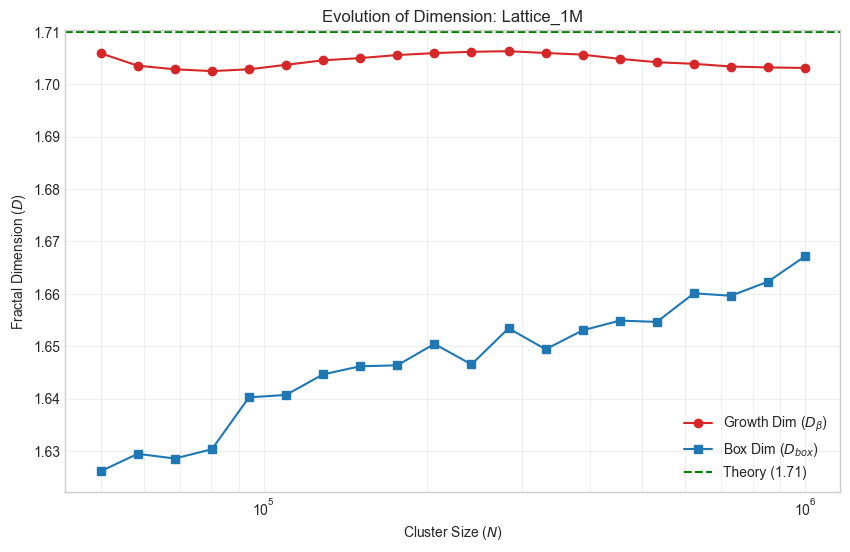

Analyzing evolution for Lattice_10M...


100%|██████████| 20/20 [01:28<00:00,  4.41s/it]


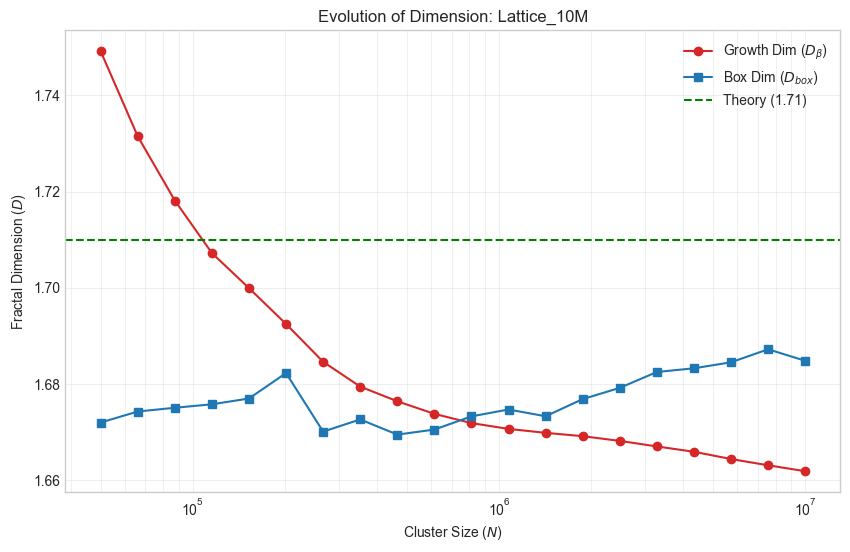

Analyzing evolution for OffLattice_1M...


100%|██████████| 20/20 [00:11<00:00,  1.79it/s]


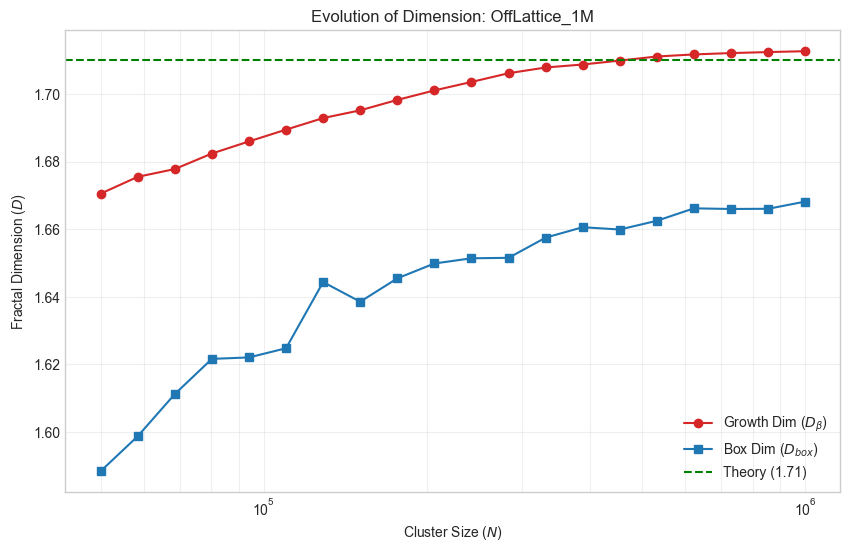

Analyzing evolution for OffLattice_10M...


100%|██████████| 20/20 [01:27<00:00,  4.38s/it]


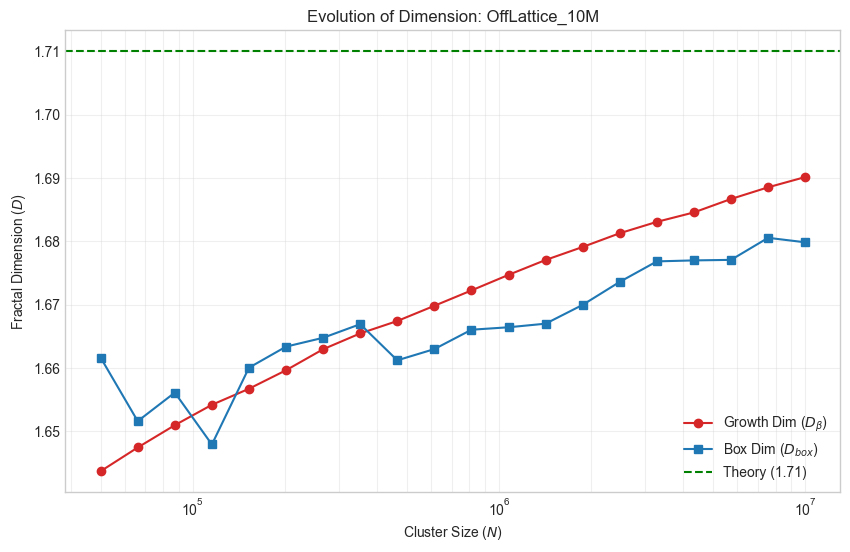

Analyzing evolution for Hybrid_1M...


100%|██████████| 20/20 [00:13<00:00,  1.43it/s]


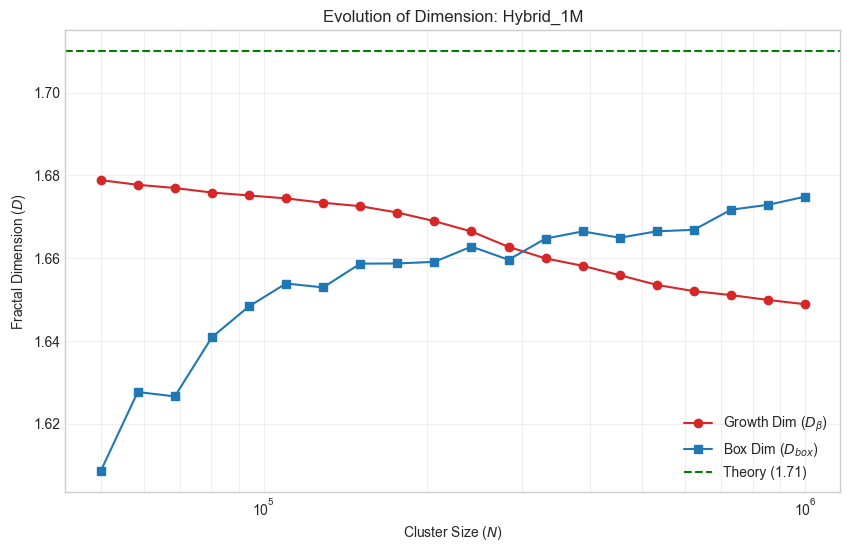

Analyzing evolution for Hybrid_10M...


100%|██████████| 20/20 [01:18<00:00,  3.90s/it]


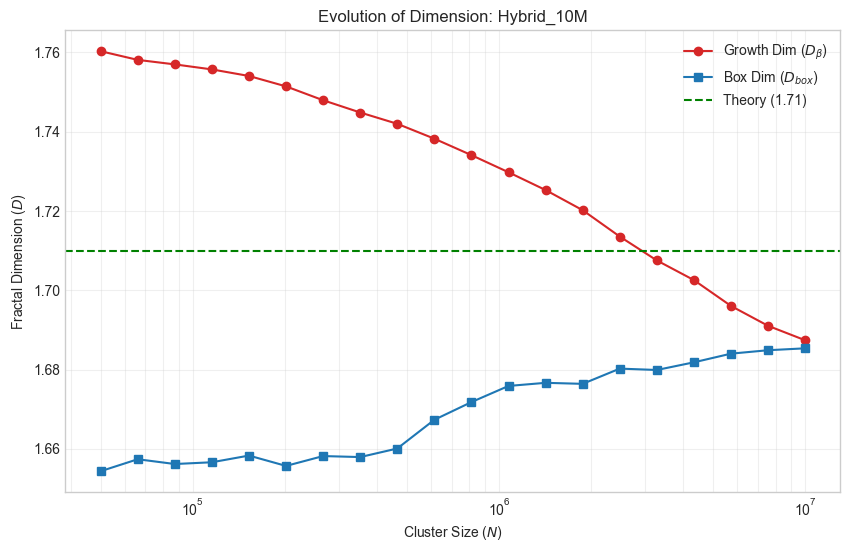

In [9]:
# --- HELPER: Growth Rate on a Subset ---
def calculate_growth_dim_subset(rg_history, current_N):
    """
    Calculates Growth Dimension (1/beta) for a specific slice of history.
    Uses Log-Resampling to match standard methodology.
    """
    # Slice history up to current_N
    if current_N > len(rg_history): current_N = len(rg_history)
    
    # We need at least ~1000 points to get a stable beta
    if current_N < 1000: return np.nan
    
    # Define time array for this slice
    t_slice = np.arange(1, current_N + 1)
    rg_slice = rg_history[:current_N]
    
    # --- Log-Resampling (The Fix) ---
    fit_start = 1000
    start_log = np.log10(fit_start)
    end_log = np.log10(current_N)
    
    num_samples = int(50 * (end_log - start_log)) # 50 points per decade
    if num_samples < 10: return np.nan

    log_indices = np.unique(np.logspace(start_log, end_log, num=num_samples).astype(int))
    log_indices = log_indices[log_indices < current_N]
    
    # Fit
    slope, _, _, _, _ = linregress(np.log(t_slice[log_indices]), np.log(rg_slice[log_indices]))
    
    # Return D = 1/beta
    return 1.0 / slope if slope != 0 else np.nan

# --- MAIN FUNCTION ---
def analyze_dimension_evolution(coords, title="Dimension Evolution"):
    """
    Computes D_box and D_growth at snapshots to visualize divergence.
    """
    N_total = len(coords)
    
    # 1. Reconstruct Rg History (if not passed separately)
    # Rg relative to Seed (Origin)
    r_sq = np.sum(coords**2, axis=1)
    cum_r_sq = np.cumsum(r_sq)
    rg_history = np.sqrt(cum_r_sq / np.arange(1, N_total + 1))
    
    # 2. Define Snapshots (Logarithmically spaced)
    # We want ~20 snapshots from 10k to Total
    min_size = 50_000
    snapshots = np.unique(np.logspace(np.log10(min_size), np.log10(N_total), num=20).astype(int))
    
    results = {
        'N': [],
        'D_box': [],
        'D_growth': []
    }
    
    print(f"Analyzing evolution for {title}...")
    
    for n in tqdm(snapshots):
        # A. Growth Dimension (Fast)
        d_beta = calculate_growth_dim_subset(rg_history, n)
        
        # B. Box Dimension (Slow - runs on subset of coords)
        # We slice the coords to simulate 'what the cluster looked like at size n'
        coords_subset = coords[:n]
        box_res = metrics.calculate_box_dim(coords_subset) # Uses your src function
        d_box = box_res['D']
        
        results['N'].append(n)
        results['D_growth'].append(d_beta)
        results['D_box'].append(d_box)

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Growth Dim (Dynamic)
    ax.plot(results['N'], results['D_growth'], 'o-', color='tab:red', label='Growth Dim ($D_{\\beta}$)')
    
    # Plot Box Dim (Geometric)
    ax.plot(results['N'], results['D_box'], 's-', color='tab:blue', label='Box Dim ($D_{box}$)')
    
    # Reference Line (1.71)
    ax.axhline(1.71, color='green', linestyle='--', label='Theory (1.71)')

    # Formatting
    ax.set_xscale('log')
    ax.set_xlabel("Cluster Size ($N$)")
    ax.set_ylabel("Fractal Dimension ($D$)")
    ax.set_title(f"Evolution of Dimension: {title}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    
    plt.show()
    
    return results

for name, coords in samples.items():
        analyze_dimension_evolution(coords, title=name)
        plt.show()

Plot the 10M clusters (used the second one found rather than first (index 1))

Target Resolution: 2048x2048 (2^11)
Target Resolution: 2048x2048 (2^11)
Target Resolution: 2048x2048 (2^11)
Figure saved successfully to: ../latex/images/heatmaps_combined.pdf


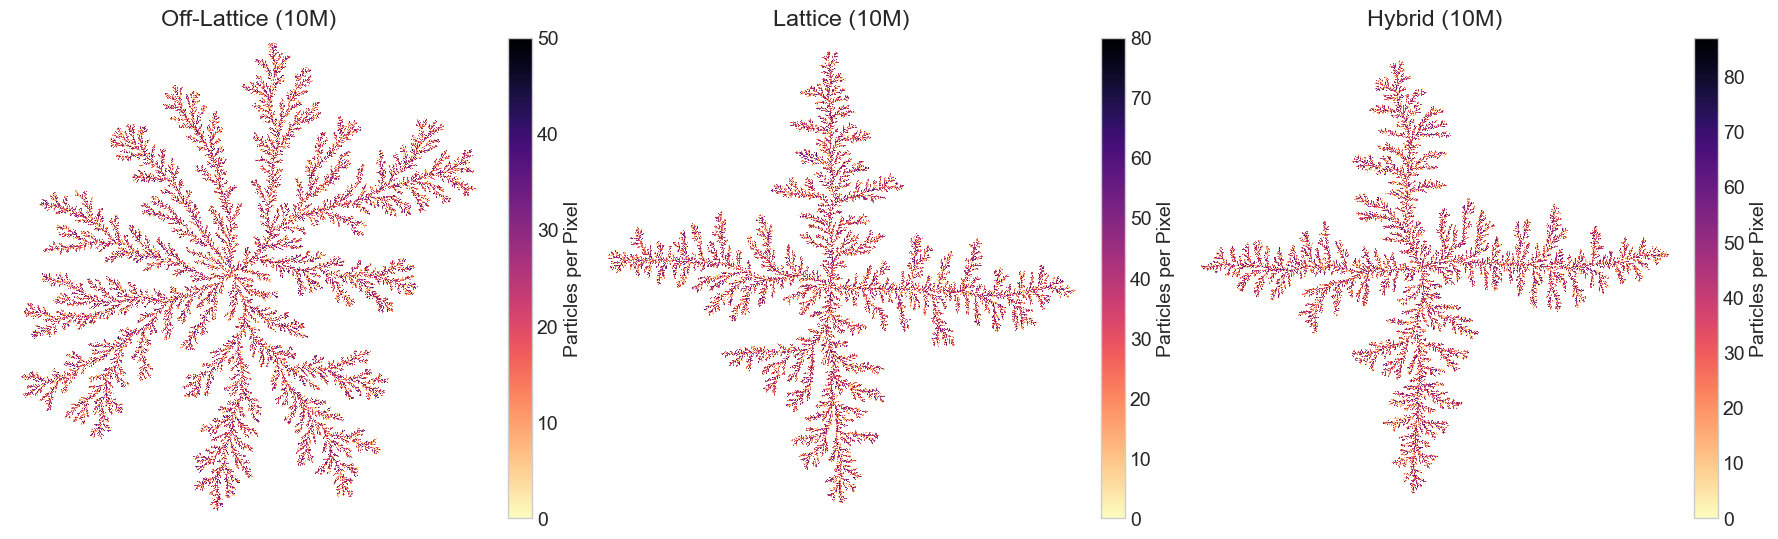

In [35]:
from src.scripts.plot_density import render_density

# ==========================================
# Script to Generate the 1x3 CG Density Grid
# ==========================================

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

models = ['OffLattice', 'Lattice', 'Hybrid']
sizes = ['10M']

for row, size in enumerate(sizes):
    for col, model in enumerate(models):
        ax = axes[col]
        
        # Pull the (N, 2) coordinate array we loaded earlier
        key = f"{model}_{size}"
        
        if key in samples:
            coords = samples[key]
            
            display_model = "Off-Lattice" if model == "OffLattice" else model
            title = f"{display_model} ({size})"
            
            render_density(
                positions=coords, 
                title=title, 
                cmap="magma_r", 
                res_power=11, 
                mode="linear", 
                ax=ax
            )
        else:
            ax.text(0.5, 0.5, f"{title}\n(Data Not Found)", ha="center", va="center", fontsize=12)
            ax.set_title(title)
            ax.axis('off')

plt.tight_layout()

# Save the figure as a PDF for LaTeX
save_path = '../latex/images/heatmaps_combined.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Figure saved successfully to: {save_path}")

plt.show()

Some CHATGPT generated plots (not particuallry useful atm, but will keep jic)

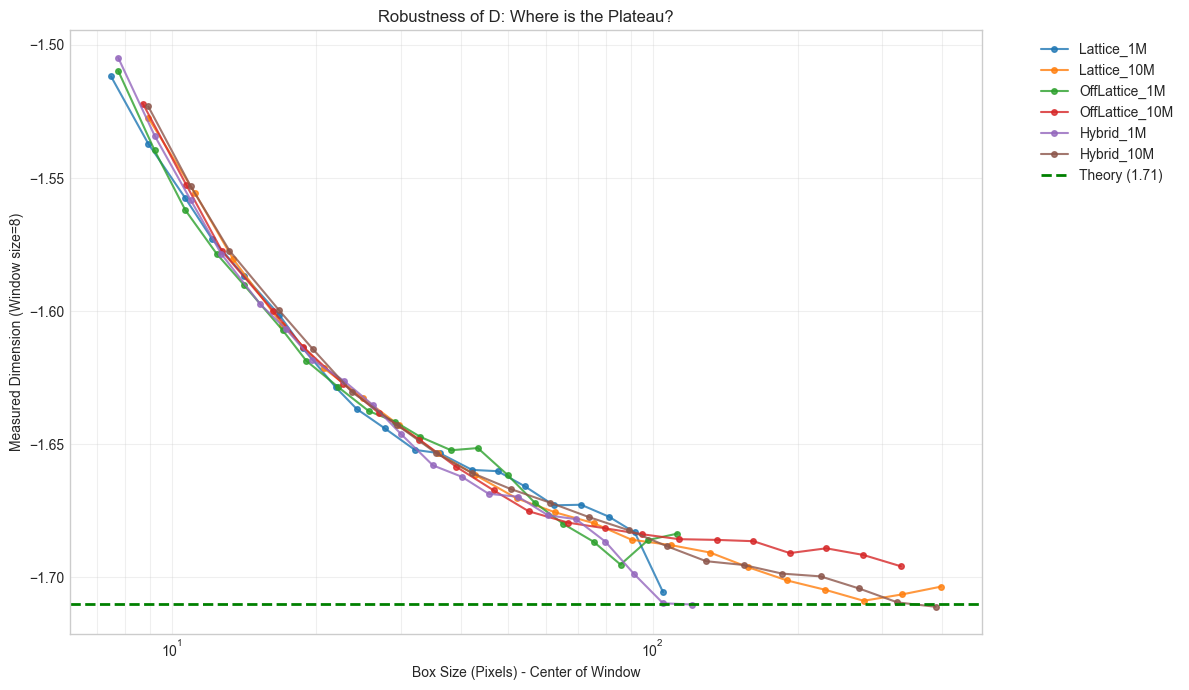

In [10]:
def cutoff_sensitivity_multi(samples_dict, window_len=8):
    """
    Plots the dimension D calculated over a sliding window of box sizes.
    Compare multiple models on one plot.
    """
    plt.figure(figsize=(12, 7))
    
    # Iterate through your loaded samples
    for name, coords in samples_dict.items():
        # 1. Get Data
        scales, counts = calculate_box_counts(coords)
        x = np.log(1 / scales) # x is log(1/eps)
        y = np.log(counts)
        
        # Check if we have enough points
        if len(scales) <= window_len:
            print(f"Skipping {name}: Too few scales ({len(scales)}) for window {window_len}")
            continue
            
        results = []
        plot_x = [] # We will plot against the physical box size
        
        # 2. Sliding Window Loop
        for i in range(len(scales) - window_len):
            # Extract the window
            x_win = x[i : i+window_len]
            y_win = y[i : i+window_len]
            
            # Fit the line
            res = linregress(x_win, y_win)
            d_val = -res.slope
            results.append(d_val)
            
            # Record the "Center" box size of this window for the X-axis
            # (Geometric mean of the start and end box sizes)
            center_box_size = np.exp((np.log(scales[i]) + np.log(scales[i+window_len])) / 2)
            plot_x.append(center_box_size)
            
        # 3. Plot Curve
        # We use semi-log X axis because box sizes grow exponentially
        plt.semilogx(plot_x, results, 'o-', markersize=4, label=name, alpha=0.8)

    # --- Formatting ---
    # Reference Lines
    plt.axhline(-1.71, color='green', linestyle='--', linewidth=2, label='Theory (1.71)')
    
    plt.xlabel("Box Size (Pixels) - Center of Window")
    plt.ylabel(f"Measured Dimension (Window size={window_len})")
    plt.title("Robustness of D: Where is the Plateau?")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Use a slightly smaller window (e.g., 8 or 10) to get more resolution
cutoff_sensitivity_multi(samples, window_len=8)

/Users/ramsaydavis/dla/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


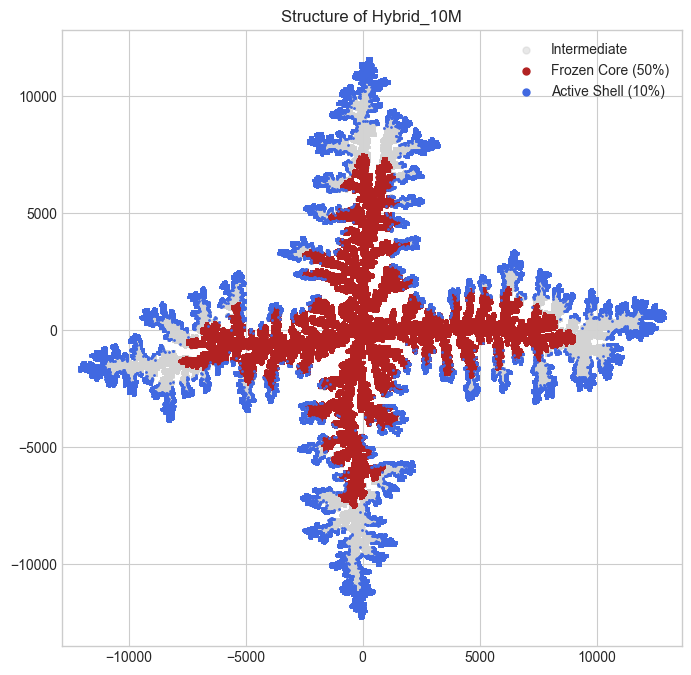

Model                | Core D     | Shell D    | Diff      
------------------------------------------------------------
Lattice_1M           | 1.6163     | 1.1705      | -0.4458
Lattice_10M          | 1.6502     | 1.2398      | -0.4104
OffLattice_1M        | 1.6207     | 1.1658      | -0.4549
OffLattice_10M       | 1.6465     | 1.2573      | -0.3892
Hybrid_1M            | 1.6270     | 1.1424      | -0.4846
Hybrid_10M           | 1.6488     | 1.2400      | -0.4088


In [11]:
def analyse_core_shell_robust(samples_dict):
    """
    Runs the Frozen Core vs Active Shell analysis on all loaded samples.
    """
    results_list = []
    
    print(f"{'Model':<20} | {'Core D':<10} | {'Shell D':<10} | {'Diff':<10}")
    print("-" * 60)
    
    for name, coords in samples_dict.items():
        N = len(coords)
        if N < 5000:
            print(f"Skipping {name}: Too small (N={N})")
            continue
            
        # 1. Slice
        core_coords = coords[:N//2]          # First 50%
        shell_coords = coords[int(N*0.9):]   # Last 10%
        
        # 2. Center the Shell (Critical!)
        # We shift the shell so its center of mass is at (0,0)
        shell_centered = shell_coords - np.mean(shell_coords, axis=0)
        
        # 3. Calculate Dimensions
        # Core
        sc, cc = calculate_box_counts(core_coords)
        # Filter for valid log values
        valid_c = (cc > 0)
        res_core = linregress(np.log(1/sc[valid_c]), np.log(cc[valid_c]))
        d_core = res_core.slope
        
        # Shell
        ss, cs = calculate_box_counts(shell_centered)
        valid_s = (cs > 0)
        res_shell = linregress(np.log(1/ss[valid_s]), np.log(cs[valid_s]))
        d_shell = res_shell.slope
        
        # 4. Store & Print
        diff = d_shell - d_core
        print(f"{name:<20} | {d_core:.4f}     | {d_shell:.4f}      | {diff:+.4f}")
        
        results_list.append({
            'Model': name,
            'D_Core': d_core,
            'D_Shell': d_shell,
            'Difference': diff,
            'N_particles': N
        })
        
    return pd.DataFrame(results_list)

def visualise_core_shell_split(coords, title="Core vs Shell"):
    """
    Visual sanity check: Plots the cluster colored by region.
    """
    N = len(coords)
    
    # Indices
    idx_core = int(N * 0.5)
    idx_shell = int(N * 0.9)
    
    plt.figure(figsize=(8, 8))
    
    # Plot Intermediate (Gray) - The "Middle History"
    plt.scatter(coords[idx_core:idx_shell, 0], coords[idx_core:idx_shell, 1], 
                c='lightgray', s=1, alpha=0.5, label='Intermediate')
    
    # Plot Core (Red)
    plt.scatter(coords[:idx_core, 0], coords[:idx_core, 1], 
                c='firebrick', s=1, label=f'Frozen Core (50%)')
    
    # Plot Shell (Blue)
    plt.scatter(coords[idx_shell:, 0], coords[idx_shell:, 1], 
                c='royalblue', s=1, label=f'Active Shell (10%)')
    
    plt.axis('equal')
    plt.legend(markerscale=5)
    plt.title(title)
    plt.show()

# --- EXECUTION ---

# 1. Run the visual check on one sample (e.g. the last one in the loop)
last_key = list(samples.keys())[-1]
visualise_core_shell_split(samples[last_key], title=f"Structure of {last_key}")

# 2. Run the numerical analysis
df_core_shell = analyse_core_shell_robust(samples)